SAMPLE - SUPERSTORE

STEP 1 :-IMPORT LIBRARIES

In [112]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
plt.style.use('seaborn-v0_8')


STEP 2 :-LOAD DATASET

In [113]:
# Loading the dataset
df = pd.read_csv("Sample - Superstore.csv", encoding='ISO-8859-1')
# Preview data
df.head(2) 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


STEP 3 :- DATA CLEANING

In [114]:
# Data Cleaning

# Check missing values
print("Missing values in each column:\n", df.isnull().sum())

# Remove duplicates
print("Duplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())

# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create year and month columns for analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()


Missing values in each column:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate rows before: 0
Duplicate rows after: 0


Step 4:- ADD UNIQUE KEY

In [115]:
# Creating a Unique Key (for Power BI)
df['Unique_Key'] = df['Order ID'] + " - " + df['Product Name']

STEP 5:- CHECKING UNIQUE AND DUPLICATE KEY

In [116]:
# Checking unique and duplicate data
print("Total Rows:", len(df))
print("Unique Order IDs:", df['Order ID'].nunique())
print("Unique Products:", df['Product Name'].nunique())
print("Duplicate Rows:", df.duplicated().sum())

Total Rows: 9994
Unique Order IDs: 5009
Unique Products: 1850
Duplicate Rows: 0


STEP 6:-EXPLORATORY DATA ANALYSIS(EDA)

Total Sales:  2297200.8603000003
Total Profit: 286397.0217


C:\Users\nitin\AppData\Local\Temp\ipykernel_13296\1730932628.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


Text(0.5, 0.98, 'EDA')

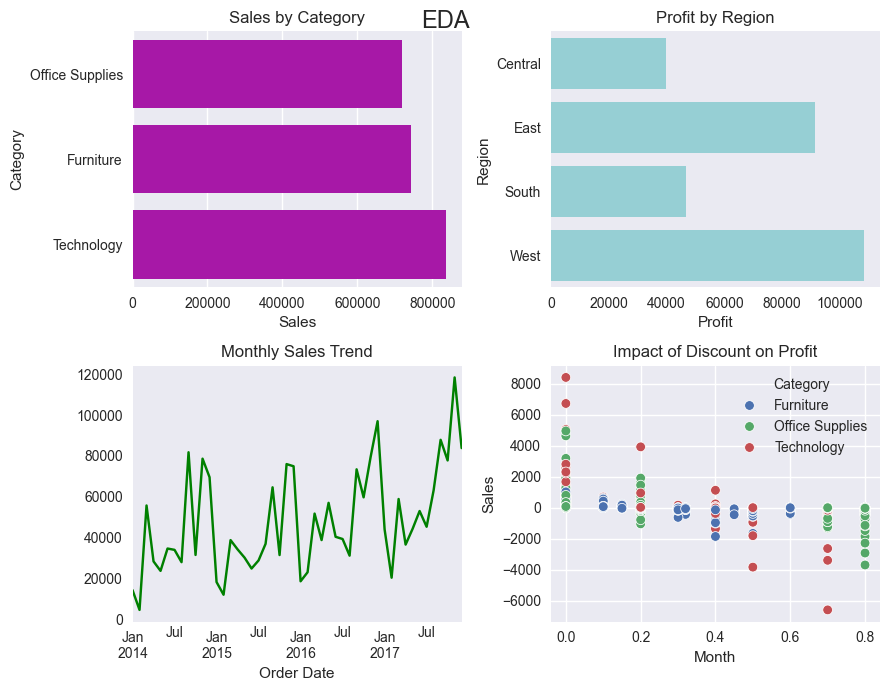

In [117]:
# Total Sales & Profit
print("Total Sales: ", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
# Sales by Category
fig, ax = plt.subplots(2, 2, figsize=(9,7))

category_sales = df.groupby('Category')['Sales'].sum().sort_values()
sns.barplot(x=category_sales.values, y=category_sales.index,ax=ax[0,0],color='m')
ax[0,0].set_title("Sales by Category")
ax[0,0].set_xlabel("Sales")
ax[0,0].set_ylabel("Category")
plt.tight_layout()
 
# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum()
sns.barplot(x=region_profit.values, y=region_profit.index,ax=ax[0,1],color='c',alpha=0.4 )
ax[0,1].grid(False)
ax[0,1].set_title("Profit by Region")
ax[0,1].set_xlabel("Profit")
ax[0,1].set_ylabel("Region")
plt.tight_layout()
 
# Monthly Sales Trend
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()
monthly_sales.plot(ax = ax[1,0],color='g')
ax[1,0].grid(False)
ax[1,0].set_title("Monthly Sales Trend")
plt.tight_layout()
 
# Discount vs Profit
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',ax = ax[1,1])
ax[1,1].set_title("Impact of Discount on Profit") 
ax[1,1].set_xlabel("Month")
ax[1,1].set_ylabel("Sales")
plt.tight_layout()
fig.suptitle("EDA",fontsize = 17,) 

STEP 7:- SAVE CLEAN DATA

In [118]:
df.to_excel("Output.xlsx", index=False)
print("✅ Cleaned dataset exported to 'Output.xlsx'")

✅ Cleaned dataset exported to 'Output.xlsx'


STEP 8:- SUMMARY

In [119]:
print("✅ Analysis Completed!")
print("Most Profitable Category: Technology")
print("Highest Profit Region: West")
print("High discounts (>30%) reduce profit significantly.")
print("Peak sales months are November and December.")

✅ Analysis Completed!
Most Profitable Category: Technology
Highest Profit Region: West
High discounts (>30%) reduce profit significantly.
Peak sales months are November and December.
